In [46]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from math import erf, sqrt, log, exp
from scipy.optimize import brentq, minimize
from scipy.integrate import quad


def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))


def bs_call_price(S0, K, T, r, q, sigma):
    if T <= 0:
        return max(S0 - K, 0.0)
    if sigma <= 0:
        F = S0 * exp((r - q) * T)
        return exp(-r * T) * max(F - K, 0.0)

    F = S0 * exp((r - q) * T)
    vol_sqrtT = sigma * sqrt(T)
    d1 = (log(F / K) + 0.5 * sigma * sigma * T) / vol_sqrtT
    d2 = d1 - vol_sqrtT
    return exp(-r * T) * (F * norm_cdf(d1) - K * norm_cdf(d2))


def implied_vol_call_from_price(C, S0, K, T, r, q, vol_low=1e-8, vol_high=5.0):

    F = S0 * exp((r - q) * T)
    lower = exp(-r*T) * max(F - K, 0.0)
    upper = exp(-r*T) * F
    C = min(max(C, lower), upper)

    if abs(C - lower) < 1e-12:
        return 0.0

    def f(sig):
        return bs_call_price(S0, K, T, r, q, sig) - C

    return brentq(f, vol_low, vol_high, maxiter=200)      #return implied vol

In [47]:
def load_spy_iv_surface(max_expiries=20, moneyness_window=(0.85, 1.15)):
    tkr = yf.Ticker("SPY")
    S0 = float(tkr.history(period="1d")["Close"].iloc[-1])

    expiries = tkr.options[:max_expiries]
    rows = []
    now = pd.Timestamp.now(tz=None)

    for exp_date in expiries:
        chain = tkr.option_chain(exp_date).calls
        chain = chain.dropna(subset=["impliedVolatility", "strike"])
        chain = chain[chain["impliedVolatility"] > 0]

        T = (pd.Timestamp(exp_date) - now).total_seconds() / (365.25 * 24 * 3600)
        if T <= 0:
            continue

        chain = chain[(chain["strike"] >= moneyness_window[0]*S0) &
                      (chain["strike"] <= moneyness_window[1]*S0)]

        for _, row in chain.iterrows():
            rows.append({"T": float(T), "K": float(row["strike"]), "iv_mkt": float(row["impliedVolatility"])})

    df = pd.DataFrame(rows).dropna().sort_values(["T","K"]).reset_index(drop=True)
    return S0, df


# K, T and Iv_market of SPY an S&P 500 ETF
S0, df_mkt = load_spy_iv_surface(max_expiries=20, moneyness_window=(0.85, 1.15))


In [48]:

df = df_mkt.copy()


df = df.dropna(subset=["T", "K", "iv_mkt"])
df = df[(df["T"] > 0) & (df["K"] > 0) & (df["iv_mkt"] > 0)]

T_min, T_max = 30/365.25, 1.0          # ~30d to 1y (violent but standard for Heston)
df = df[df["T"].between(T_min, T_max)]


m_lo, m_hi = 0.90, 1.10
df = df[df["K"].between(m_lo*S0, m_hi*S0)]


df = df[df["iv_mkt"].between(0.05, 1.00)]


nT = 6
Ts = np.array(sorted(df["T"].unique()))
if len(Ts) > nT:
    Ts_pick = Ts[np.linspace(0, len(Ts)-1, nT).astype(int)]
else:
    Ts_pick = Ts
df = df[df["T"].isin(Ts_pick)]


nK = 15
dfs = []
for T in sorted(df["T"].unique()):
    sub = df[df["T"] == T].sort_values("K")

    # if you have too many points, downsample uniformly in strike space
    if len(sub) > nK:
        idx = np.linspace(0, len(sub)-1, nK).astype(int)
        sub = sub.iloc[idx]

    dfs.append(sub)

df = (pd.concat(dfs, ignore_index=True)
        .drop_duplicates(subset=["T", "K"])
        .sort_values(["T", "K"])
        .reset_index(drop=True))

print("After robust filters:", df.shape)
df_mkt = df

After robust filters: (90, 3)


In [49]:
def heston_cf(u, T, S0, r, q, kappa, theta, xi, rho, v0):

    i = 1j
    x0 = np.log(S0)
    a = kappa * theta

    d = np.sqrt((rho*xi*i*u - kappa)**2 + xi*xi*(i*u + u*u))
    g = (kappa - rho*xi*i*u - d) / (kappa - rho*xi*i*u + d)

    exp_dT = np.exp(-d*T)
    G = (1 - g*exp_dT) / (1 - g)

    C = (r - q)*i*u*T + (a/(xi*xi)) * ((kappa - rho*xi*i*u - d)*T - 2*np.log(G))
    D = ((kappa - rho*xi*i*u - d) / (xi*xi)) * ((1 - exp_dT) / (1 - g*exp_dT))

    return np.exp(C + D*v0 + i*u*x0)


def heston_call_price_cf(S0, K, T, r, q, params, umax=100.0):

    kappa, theta, xi, rho, v0 = params

    def integrand_P1(u):
        i = 1j
        phi = heston_cf(u - i, T, S0, r, q, kappa, theta, xi, rho, v0)
        phi_mi = heston_cf(-i, T, S0, r, q, kappa, theta, xi, rho, v0)
        return np.real(np.exp(-1j*u*np.log(K)) * phi / (1j*u*phi_mi))

    def integrand_P2(u):
        phi = heston_cf(u, T, S0, r, q, kappa, theta, xi, rho, v0)
        return np.real(np.exp(-1j*u*np.log(K)) * phi / (1j*u))


    P1 = 0.5 + (1/np.pi) * quad(lambda uu: integrand_P1(uu), 1e-8, umax, limit=200)[0]
    P2 = 0.5 + (1/np.pi) * quad(lambda uu: integrand_P2(uu), 1e-8, umax, limit=200)[0]

    return S0*np.exp(-q*T)*P1 - K*np.exp(-r*T)*P2

In [50]:
def heston_model_iv_grid(df, S0, r, q, params):
    ivs = []
    for T, K in zip(df["T"].values, df["K"].values):
        C = heston_call_price_cf(S0, float(K), float(T), r, q, params)
        iv = implied_vol_call_from_price(C, S0, float(K), float(T), r, q)
        ivs.append(iv)
    return np.array(ivs)


def calibration_loss(x, df, S0, r, q, weights=None):
    # x = [kappa, theta, xi, rho, v0]
    kappa, theta, xi, rho, v0 = x

    if kappa <= 0 or theta <= 0 or xi <= 0 or v0 <= 0 or not (-0.999 < rho < 0.999):
        return 1e6

    iv_model = heston_model_iv_grid(df, S0, r, q, x)
    iv_mkt = df["iv_mkt"].values

    err = iv_model - iv_mkt
    if weights is None:
        return float(np.mean(err**2))
    return float(np.mean(weights * err**2))

In [51]:
# Fixed rates (demo)
r = 0.02
q = 0.00

# initial guess (reasonable)
x0 = np.array([2.0, 0.04, 0.5, -0.7, 0.04])  # [kappa, theta, xi, rho, v0]


bounds = [
    (0.05, 20.0),   # kappa
    (1e-4,  1.0),   # theta
    (1e-3,  5.0),   # xi
    (-0.999, 0.999),# rho
    (1e-4,  1.0),   # v0
]

res = minimize(
    calibration_loss,
    x0=x0,
    args=(df_mkt, S0, r, q, None),
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 50}
)

print("Success:", res.success)
print("Message:", res.message)
print("Calibrated params [kappa, theta, xi, rho, v0]:", res.x)
print("Final loss (MSE IV):", res.fun)

Success: True
Message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Calibrated params [kappa, theta, xi, rho, v0]: [ 1.99430605  0.0773576   0.69163759 -0.95815231  0.02617423]
Final loss (MSE IV): 0.00022743444148586955


In [52]:

def plot_smiles_by_maturity(df, S0, r, q, params=None, title="IV smiles",
                            Ts_to_plot=None, tol=0.01, savepath=None):

    plt.figure(figsize=(9,5))

    # If user didn't specify maturities: plot all unique T (not recommended for readability)
    if Ts_to_plot is None:
        Ts_selected = sorted(df["T"].unique())
    else:
        Ts_selected = []
        for Ttar in Ts_to_plot:
            # find nearest available T
            Tnear = df.loc[(df["T"] - Ttar).abs().idxmin(), "T"]
            if abs(Tnear - Ttar) <= tol:
                Ts_selected.append(float(Tnear))
            else:
                print(f"[WARN] No maturity within tol for target T={Ttar:.4f}. Closest is {Tnear:.4f} (gap={abs(Tnear-Ttar):.4f})")

        Ts_selected = sorted(set(Ts_selected))

    if len(Ts_selected) == 0:
        print("ERROR")
        return

    any_plotted = False

    for T in Ts_selected:
        sub = df[np.isclose(df["T"], T, atol=1e-12)].sort_values("K")
        if len(sub) == 0:
            continue

        plt.plot(sub["K"], sub["iv_mkt"], marker="o", linewidth=1, label=f"Mkt T={T:.2f}")
        any_plotted = True

        if params is not None:
            iv_model = heston_model_iv_grid(sub, S0, r, q, params)
            plt.plot(sub["K"], iv_model, linestyle="--", linewidth=2, label=f"Heston T={T:.2f}")

    if not any_plotted:
        print("ERROR")
        return

    plt.xlabel("Strike K")
    plt.ylabel("Implied Volatility")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
        print(f"Saved figure to: {savepath}")

    plt.show()

Saved figure to: smiles_after_selected_T.png


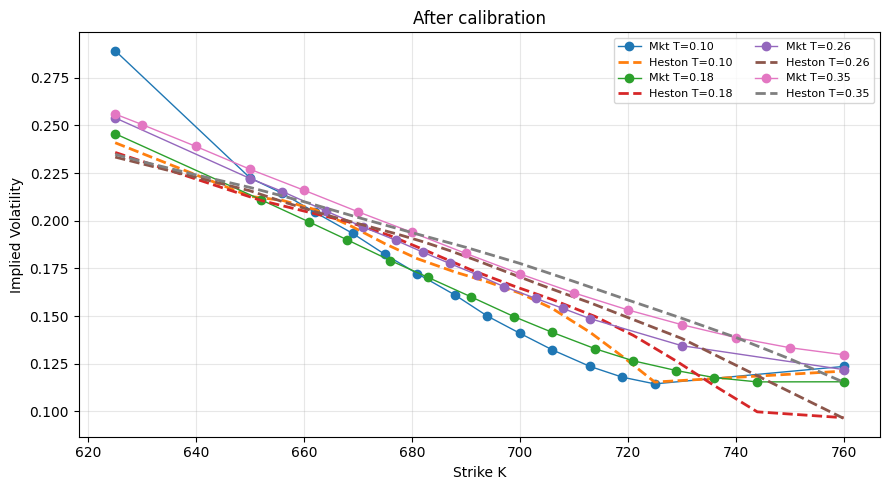

In [53]:
Ts = [0.10, 0.18, 0.26, 0.35]
plot_smiles_by_maturity(
    df_mkt, S0, r, q,
    params=res.x,
    title="After calibration",
    Ts_to_plot=Ts,
    tol=0.03,  
    savepath="smiles_after_selected_T.png"
)


In [54]:
params_df = pd.DataFrame({
    "parameter": ["kappa", "theta", "xi", "rho", "v0"],
    "value": res.x
})
display(params_df)

,parameter,value
0,kappa,1.994306
1,theta,0.077358
2,xi,0.691638
3,rho,-0.958152
4,v0,0.026174
